# Project Overview

* In this project, we will try predict the survival status of Titanic passengers using Logistic Regression. The dataset includes information such as demographic attributes (age, sex), socioeconomic status (fare, class), and other relevant features.

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### 2. Load the Data

In [2]:
df = pd.read_csv('titanic_dataset.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 3. Data Cleaning

In [5]:
#To check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

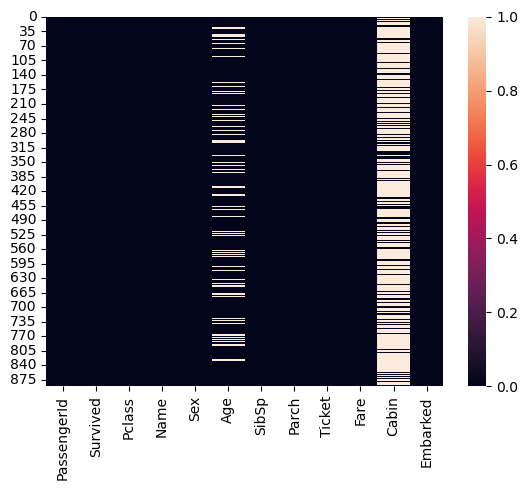

In [6]:
sns.heatmap(df.isnull())

* We have some missing values in Age and Cabin column, we will drop the Cabin column and impute values in Age.

In [7]:
#Since Cabin column has a lot of null values so let's drop this column
df.drop(columns = ['Cabin'], inplace = True)

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [9]:
# Fill null values in Age column with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [10]:
df['Age'].isnull().sum()

0

In [11]:
#Drop 2 rows where Embareked is null
df.dropna(inplace = True)

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### 4. Exploratory Data Analysis (EDA)

#### 4.1 Create a countplot to check survival rate

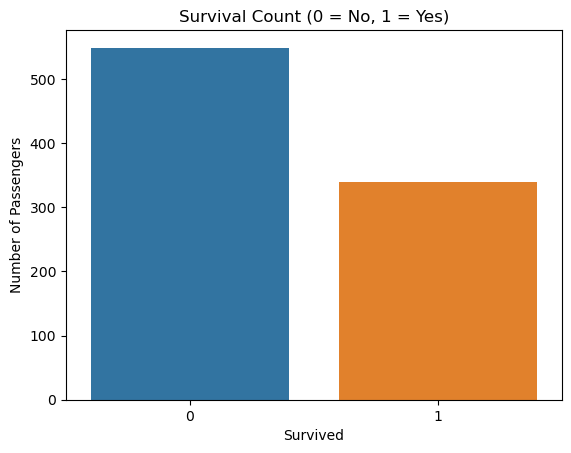

In [13]:
sns.countplot(x = 'Survived', data = df)
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

* Shows that most passengers did not survive — gives an idea of class imbalance

#### 4.2:- Check survival rate by gender wise using countplot

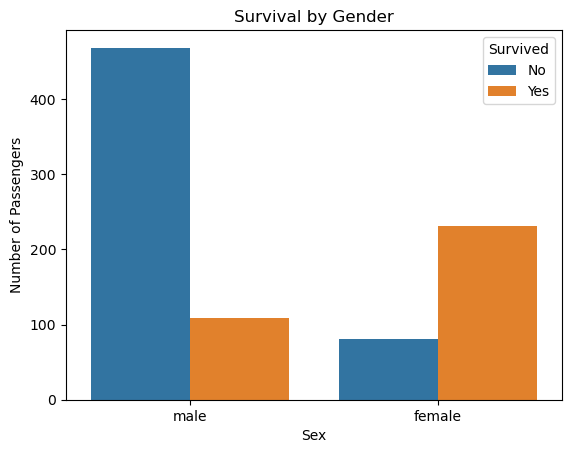

In [14]:
sns.countplot(data = df, x = 'Sex', hue = 'Survived')
plt.title("Survival by Gender")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

* Females had a much higher survival rate than males.

#### 4.3:- Check age distribution of passengers using histogram

C:\Users\rm217\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


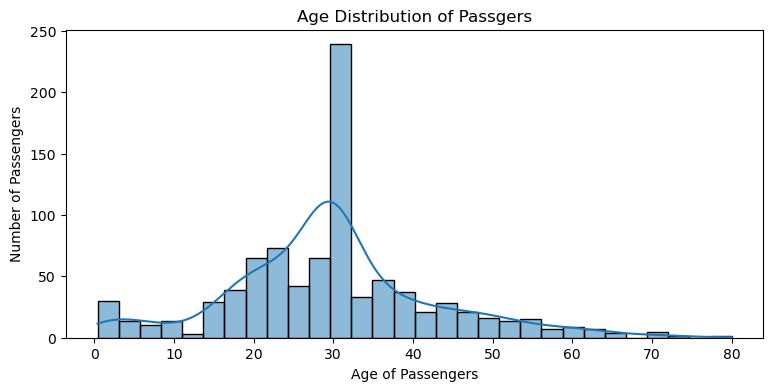

In [15]:
plt.figure(figsize = (9,4))
sns.histplot(df['Age'], bins = 30, kde = True)
plt.title('Age Distribution of Passgers')
plt.xlabel('Age of Passengers')
plt.ylabel('Number of Passengers')
plt.show()

* Average age of the passenger was between 20 to 30 that means mostly young passengers.

#### 4.4 Check survival rate by class

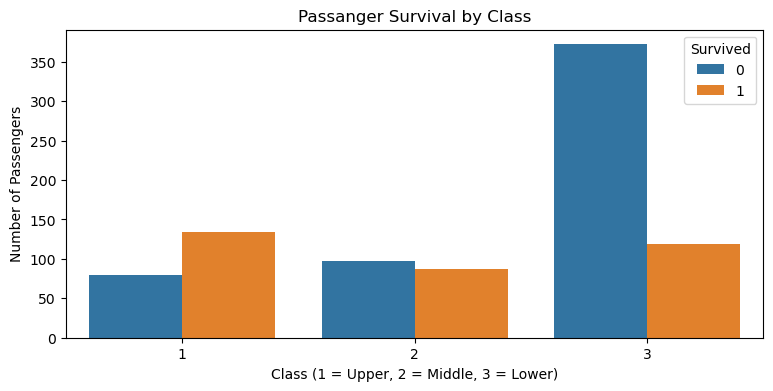

In [16]:
plt.figure(figsize = (9,4))
sns.countplot(data = df, x = df['Pclass'], hue = 'Survived')
plt.title('Passanger Survival by Class')
plt.xlabel("Class (1 = Upper, 2 = Middle, 3 = Lower)")
plt.ylabel('Number of Passengers')
plt.show()

* Above plot shows lowest survival rate for 3rd class

#### 4.5 Convert categorical variables into numerical variables, as algorithms cannot directly handle categorical data

In [17]:
sex = pd.get_dummies(df['Sex'], dtype = int, drop_first = True)

In [18]:
embarked = pd.get_dummies(df['Embarked'], dtype = int, drop_first = True)

In [19]:
embarked.head(3)

,Q,S
0,0,1
1,0,0
2,0,1


In [20]:
# Now let's concatenate these created columns

df = pd.concat([df,sex,embarked], axis = 1)

In [21]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,0,0


In [22]:
#drop unnecessary columns

df.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis = 1, inplace = True)

In [23]:
df.head(2)

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0


* Now our dataset is ready as it has only numerical columns

### 6. Create feature and label  and split the data

In [24]:
# Let's separate the data in features and label

X = df.drop('Survived', axis = 1) #Apart from Survived rest are our features
y = df['Survived'] #Survived is our lable

In [25]:
# Let's split our dataset into training and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 101)

### 7. Build the Logistic Regression Model

In [26]:
# Let's train our LogisticRegression model on training data

from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression()

logmodel.fit(X_train, y_train)

C:\Users\rm217\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
#let's predict on test data 

y_pred = logmodel.predict(X_test)

### 8. Evaluate the Model

* For classification task, to evaluate our model, we can either use classification_report or confusion_matrix

In [28]:
#Let's evaluate our model using classification_report to check accuracy, precision, and recall

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       163
           1       0.84      0.68      0.75       104

    accuracy                           0.82       267
   macro avg       0.83      0.80      0.81       267
weighted avg       0.83      0.82      0.82       267



In [29]:
#Let's evaluate our model using confusion_matrix to check TP,TN,FP,FN

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred)

array([[149,  14],
       [ 33,  71]], dtype=int64)

* Above image of Confusion matrix is an N x N matrix used for evaluating the performance of a classification model

## Example to understand confusion matrix 

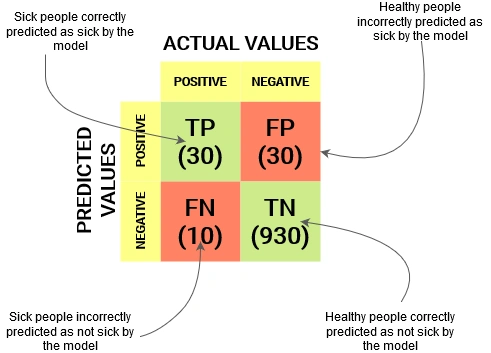

### Precision vs. Recall

* Precision tells us how many of the correctly predicted cases actually turned out to be positive.

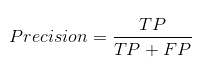

* Recall tells us how many of the actual positive cases we were able to predict correctly with our model.

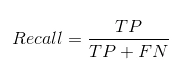

## Link of this file given in the description 